# Xenofobia en redes sociales durante la pandemia de COVID-19 en Argentina
## Analisis vinculado al DNU 70/10 y/o a extranjeros

## Análisis para artículo en Revista PERIPLOS

**Autora:** Natalia De Bandi  
**Fecha:** Marzo 2026  



## 1. Origen del dataset

### Fuente: Proyecto PIUBAMAS / HuggingFace

El dataset utilizado es `tweets_medios_arg.csv`, generado a partir del conjunto de datos público disponible en HuggingFace:

> **Dataset:** [`piubamas/articles_and_comments`](https://huggingface.co/datasets/piubamas/articles_and_comments)  
> **Proyecto:** PIUBAMAS (Programación UBA - Minería y Análisis de Sentimientos en Arabe y Español)

El dataset se encuentra etiquetado sobre discursos discriminatorios y de odio con este etiquetador:

> **Clasificador:** [`piuba-bigdata/beto-contextualized-hate-speech`](https://huggingface.co/piuba-bigdata/beto-contextualized-hate-speech)

Las categorías de odio etiquetadas son:
| Etiqueta | Descripción |
|----------|-------------|
| `CALLS` | Llamados a la acción violenta |
| `WOMEN` | Odio hacia mujeres |
| `LGBTI` | Odio hacia personas LGBTI+ |
| `RACISM` | Racismo / xenofobia |
| `CLASS` | Odio por clase social |
| `POLITICS` | Odio político |
| `DISABLED` | Odio hacia personas con discapacidad |
| `APPEARANCE` | Odio por apariencia física |
| `CRIMINAL` | Estigmatización criminal |



Los medios argentinos incluidos son:

| Usuario Twitter | Medio |
|-----------------|-------|
| `clarincom` | Clarín |
| `LANACION` | La Nación |
| `infobae` | Infobae |
| `pagina12` | Página 12 |
| `perfilcom` | Perfil |
| `cronica` | Crónica |
| `izquierdadiario` | La Izquierda Diario |
| `laderechadiario` | La Derecha Diario |
| `laderechamedios` | La Derecha Medios |

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

## 2. Carga del dataset

In [3]:
df = pd.read_csv('data/tweets_medios_arg.csv', parse_dates=['date_tweet'])

print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
df.head()

Dataset cargado: 5,493,397 filas × 18 columnas


,id,tweet_id_noticia,title,resumen,medio,date_tweet,text,user_id,HATEFUL,CALLS,WOMEN,LGBTI,RACISM,CLASS,POLITICS,DISABLED,APPEARANCE,CRIMINAL
0,0,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:03:00.900,@clarincom A mi me preocupa el trabajo.. La ev...,1532596098,0,0,0,0,0,0,0,0,0,0
1,1,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:05:04.500,@clarincom Lo que preocupa. https://t.co/Vmf9V...,1222094021687943168,0,0,0,0,0,0,0,0,0,0
2,2,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:06:03.100,@clarincom Lo que les preocupa. https://t.co/P...,1222094021687943168,0,0,0,0,0,0,0,0,0,0
3,3,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:11:02.300,@clarincom Le recomendaríamos al presidente de...,582286194,0,0,0,0,0,0,0,0,0,0
4,4,1376940813968609288,Segunda ola de coronavirus: preocupan las reun...,Segunda ola de coronavirus: preocupan las reun...,clarincom,2021-03-30 17:26:00.600,@clarincom Para salvar al correo de la quiebra...,951552761988034560,0,0,0,0,0,0,0,0,0,0


## 3. Descripción del dataset

### 3.1 Estructura de columnas

In [4]:
# Descripción de columnas y tipos de datos
col_desc = {
    'id': 'Índice del comentario dentro de la noticia',
    'tweet_id_noticia': 'ID del tweet de la noticia a la que responde el comentario',
    'title': 'Título de la noticia',
    'resumen': 'Texto del tweet de la noticia (resumen)',
    'medio': 'Cuenta de Twitter del medio de comunicación',
    'date_tweet': 'Fecha y hora del comentario (UTC)',
    'text': 'Texto del comentario',
    'user_id': 'ID del usuario que publicó el comentario',
    'HATEFUL': 'Indicador agregado: 1 si el comentario fue clasificado como odioso en alguna categoría',
    'CALLS': 'Llamados a la violencia',
    'WOMEN': 'Odio hacia mujeres',
    'LGBTI': 'Odio hacia LGBTI+',
    'RACISM': 'Racismo / xenofobia',
    'CLASS': 'Odio por clase social',
    'POLITICS': 'Odio político',
    'DISABLED': 'Odio hacia personas con discapacidad',
    'APPEARANCE': 'Odio por apariencia física',
    'CRIMINAL': 'Estigmatización criminal',
}

desc_df = pd.DataFrame({
    'Columna': col_desc.keys(),
    'Descripción': col_desc.values(),
    'Tipo': [df[c].dtype for c in col_desc.keys()]
})
display(desc_df)

,Columna,Descripción,Tipo
0,id,Índice del comentario dentro de la noticia,int64
1,tweet_id_noticia,ID del tweet de la noticia a la que responde e...,int64
2,title,Título de la noticia,str
3,resumen,Texto del tweet de la noticia (resumen),str
4,medio,Cuenta de Twitter del medio de comunicación,str
5,date_tweet,Fecha y hora del comentario (UTC),datetime64[us]
6,text,Texto del comentario,str
7,user_id,ID del usuario que publicó el comentario,int64
8,HATEFUL,Indicador agregado: 1 si el comentario fue cla...,int64
9,CALLS,Llamados a la violencia,int64


### 3.2 Estadísticas generales

In [5]:
print("=" * 55)
print("ESTADÍSTICAS GENERALES DEL DATASET")
print("=" * 55)
print(f"  Total de comentarios:      {len(df):>12,}")
print(f"  Comentarios odiosos:       {df['HATEFUL'].sum():>12,}  ({df['HATEFUL'].mean()*100:.1f}%)")
print(f"  Comentarios no odiosos:    {(df['HATEFUL']==0).sum():>12,}  ({(df['HATEFUL']==0).mean()*100:.1f}%)")
print(f"  Rango temporal:            {df['date_tweet'].min().date()} → {df['date_tweet'].max().date()}")
print(f"  Medios cubiertos:          {df['medio'].nunique():>12,}")
print(f"  Noticias únicas:           {df['tweet_id_noticia'].nunique():>12,}")
print(f"  Usuarios únicos:           {df['user_id'].nunique():>12,}")

ESTADÍSTICAS GENERALES DEL DATASET
  Total de comentarios:         5,493,397
  Comentarios odiosos:            340,593  (6.2%)
  Comentarios no odiosos:       5,152,804  (93.8%)
  Rango temporal:            2020-02-10 → 2021-06-25
  Medios cubiertos:                     9
  Noticias únicas:                330,600
  Usuarios únicos:                402,870


### 3.3 Distribución por medio de comunicación

In [6]:
medios_stats = df.groupby('medio').agg(
    comentarios=('text', 'count'),
    odiosos=('HATEFUL', 'sum'),
    noticias=('tweet_id_noticia', 'nunique'),
    primer_tweet=('date_tweet', 'min'),
    ultimo_tweet=('date_tweet', 'max')
).sort_values('comentarios', ascending=False)

medios_stats['% odio'] = (medios_stats['odiosos'] / medios_stats['comentarios'] * 100).round(2)
medios_stats['primer_tweet'] = medios_stats['primer_tweet'].dt.date
medios_stats['ultimo_tweet'] = medios_stats['ultimo_tweet'].dt.date

display(medios_stats[['comentarios', 'noticias', 'odiosos', '% odio', 'primer_tweet', 'ultimo_tweet']])

,comentarios,noticias,odiosos,% odio,primer_tweet,ultimo_tweet
medio,,,,,,
infobae,1691830,98751,105128,6.21,2020-02-10,2021-06-25
LANACION,1574297,51536,94459,6.00,2020-02-10,2021-06-25
clarincom,1486018,66267,96918,6.52,2020-02-10,2021-06-25
pagina12,221971,29184,10242,4.61,2020-02-13,2021-06-25
cronica,205588,50316,15371,7.48,2020-02-10,2021-06-24
perfilcom,159860,21056,7237,4.53,2020-02-10,2021-06-25
laderechamedios,69944,2800,4726,6.76,2020-07-14,2021-02-26
laderechadiario,65907,2904,4869,7.39,2020-02-11,2021-06-24
izquierdadiario,17982,7786,1643,9.14,2020-03-06,2021-06-22


### 3.4 Cobertura temporal del dataset

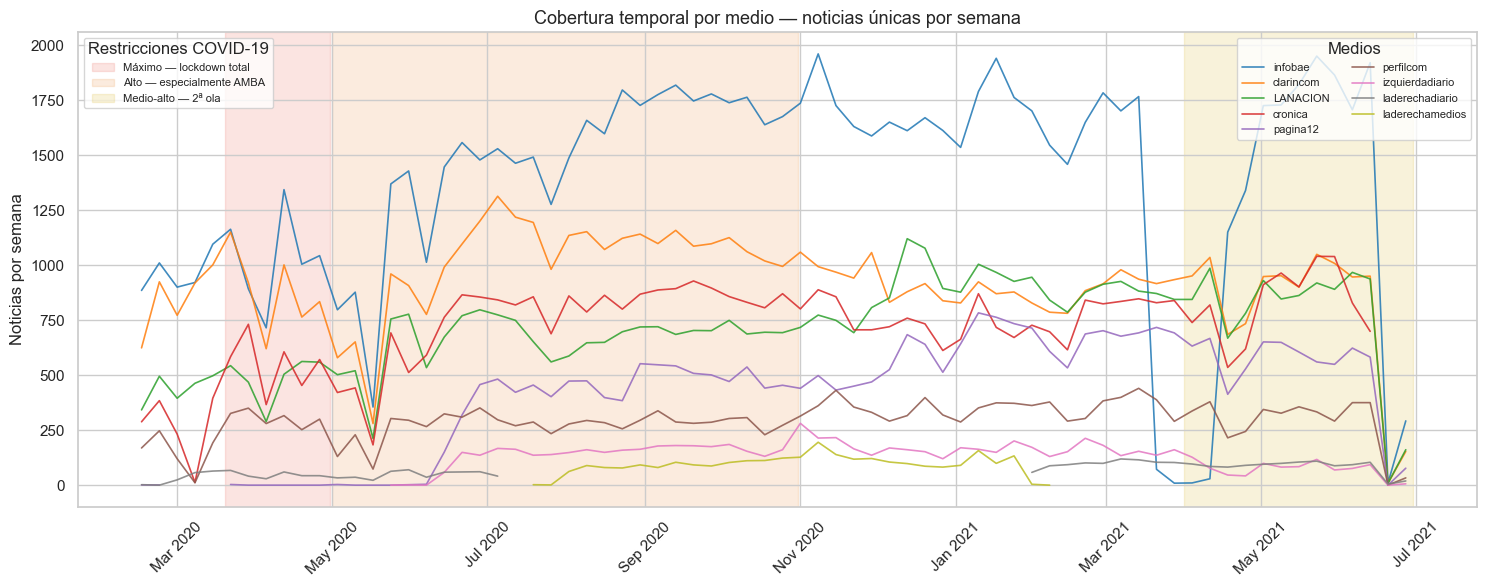

In [7]:
import matplotlib.dates as mdates

# --- Noticias únicas por SEMANA y por medio ---
df_noticias = df.drop_duplicates(subset=['tweet_id_noticia', 'medio']).copy()

noticias_semanales = (
    df_noticias
    .groupby(['medio', pd.Grouper(key='date_tweet', freq='W')])['tweet_id_noticia']
    .count()
    .unstack('medio')
)

# Rango completo semanal → NaN donde no hay datos (rompe la línea)
semana_rango = pd.date_range(noticias_semanales.index.min(), noticias_semanales.index.max(), freq='W')
noticias_semanales = noticias_semanales.reindex(semana_rango)

# Reemplazar 0 por NaN también (semanas con cero noticias = hueco)
noticias_semanales = noticias_semanales.replace(0, float('nan'))

# Orden por volumen total
orden_medios = noticias_semanales.sum().sort_values(ascending=False).index.tolist()

# --- Períodos de restricciones ---
periodos = [
    (pd.Timestamp('2020-03-20'), pd.Timestamp('2020-04-30'), '#e74c3c', 'Máximo — lockdown total'),
    (pd.Timestamp('2020-05-01'), pd.Timestamp('2020-10-31'), '#e67e22', 'Alto — especialmente AMBA'),
    (pd.Timestamp('2021-04-01'), pd.Timestamp('2021-06-30'), '#d4ac0d', 'Medio-alto — 2ª ola'),
]

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(15, 6))

# Franjas de pandemia (fondo)
franja_handles = []
for inicio, fin, color, label in periodos:
    patch = ax.axvspan(inicio, fin, alpha=0.15, color=color, zorder=0, label=label)
    franja_handles.append(patch)

# Líneas por medio
colores = plt.cm.tab10.colors
linea_handles = []
for i, medio in enumerate(orden_medios):
    serie = noticias_semanales[medio]
    linea, = ax.plot(serie.index, serie.values,
                     label=medio, color=colores[i % len(colores)],
                     linewidth=1.2, alpha=0.85)
    linea_handles.append(linea)

# Ejes y formato
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
ax.set_ylabel('Noticias por semana')
ax.set_title('Cobertura temporal por medio — noticias únicas por semana', fontsize=13)

# Dos leyendas separadas
ley_medios = ax.legend(handles=linea_handles, loc='upper right', fontsize=8,
                       title='Medios', ncol=2)
ax.add_artist(ley_medios)
ax.legend(handles=franja_handles, loc='upper left', fontsize=8,
          title='Restricciones COVID-19')

plt.tight_layout()
plt.savefig('outputs/cobertura_temporal_medios.png', dpi=150, bbox_inches='tight')
plt.show()


In [8]:
import html as htmllib
from IPython.display import display, HTML

# ── Selección de noticia representativa (top en comentarios RACISM) ──────────
candidatas = (
    df[df['RACISM'] == 1]
    .groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
    .size()
    .reset_index(name='n_racism')
    .query('n_racism >= 5')
    .sort_values('n_racism', ascending=False)
)

# Índice 2 para tener variedad (cambiar por 0, 1, 3... para ver otras noticias)
row = candidatas.iloc[2]
tweet_id  = row['tweet_id_noticia']
medio     = row['medio']
titulo    = htmllib.escape(str(row['title']))
resumen   = htmllib.escape(str(row['resumen'])[:300])

todos = df[df['tweet_id_noticia'] == tweet_id].copy()
fecha_str         = todos['date_tweet'].min().strftime('%d %b %Y')
total_comentarios = len(todos)
n_racism          = row['n_racism']

# 4 comentarios con RACISM=1
odiosos = todos[todos['RACISM'] == 1].head(4)

url_tweet = f"https://twitter.com/{medio}/status/{tweet_id}"

# ── Badges de categorías ─────────────────────────────────────────────────────
CATEGORIAS = {
    'RACISM':     ('#c0392b', 'Xenofobia / Racismo'),
    'CALLS':      ('#922b21', 'Llamado a violencia'),
    'WOMEN':      ('#884ea0', 'Odio a mujeres'),
    'LGBTI':      ('#1a5276', 'Odio LGBTI+'),
    'CLASS':      ('#1e8449', 'Odio por clase social'),
    'POLITICS':   ('#d4ac0d', 'Odio político'),
    'DISABLED':   ('#2471a3', 'Odio a discapacidad'),
    'APPEARANCE': ('#ca6f1e', 'Odio por apariencia'),
    'CRIMINAL':   ('#5d6d7e', 'Estigma criminal'),
}

def make_badges(c_row):
    badges = ''
    for col, (color, label) in CATEGORIAS.items():
        if c_row.get(col, 0) == 1:
            badges += (f'<span style="background:{color};color:white;'
                       f'padding:2px 8px;border-radius:10px;font-size:11px;'
                       f'margin-right:4px;">{label}</span>')
    return badges or '<span style="color:#aaa;font-size:11px;">sin etiqueta</span>'

# ── Nombres legibles de medios ────────────────────────────────────────────────
NOMBRES = {
    'clarincom': 'Clarín', 'LANACION': 'La Nación', 'infobae': 'Infobae',
    'pagina12': 'Página 12', 'cronica': 'Crónica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}
nombre_medio = NOMBRES.get(medio, medio)

# ── Bloque de comentarios ─────────────────────────────────────────────────────
comentarios_html = ''
for _, c in odiosos.iterrows():
    texto  = htmllib.escape(str(c['text'])[:280])
    fecha_c = c['date_tweet'].strftime('%d %b %Y %H:%M')
    comentarios_html += f"""
    <div style="margin:10px 0 10px 36px; padding:12px 15px; background:#fff;
                border-left:3px solid #e74c3c; border-radius:6px;
                box-shadow:0 1px 3px rgba(0,0,0,0.08);">
      <div style="font-size:12px; color:#888; margin-bottom:6px;">
        💬 Usuario anónimo · {fecha_c}
      </div>
      <div style="font-size:14px; color:#222; line-height:1.6;">
        {texto}
      </div>
      <div style="margin-top:8px;">
        {make_badges(c)}
      </div>
    </div>"""

# ── HTML final ────────────────────────────────────────────────────────────────
html = f"""
<div style="font-family:'Segoe UI',Arial,sans-serif; max-width:700px; margin:20px auto;">

  <!-- Encabezado explicativo -->
  <div style="background:#e8f4fd; border-radius:8px; padding:10px 16px;
              margin-bottom:16px; font-size:13px; color:#2471a3; line-height:1.6;">
    <strong>Estructura del dataset</strong><br>
    Cada fila representa un <em>comentario</em> asociado a una <em>noticia</em> publicada
    por un medio en Twitter/X. Esta noticia recibió
    <strong>{total_comentarios:,} comentarios</strong>,
    de los cuales <strong>{n_racism} fueron clasificados como xenofobia/racismo</strong>.
    Se muestran 4 a modo de ejemplo.
  </div>

  <!-- Tweet del medio (noticia) -->
  <div style="background:#f7f9fa; border:1px solid #dce1e7; border-radius:12px;
              padding:18px 20px;">

    <!-- Cabecera usuario -->
    <div style="display:flex; align-items:center; margin-bottom:12px;">
      <div style="width:42px; height:42px; background:#1da1f2; border-radius:50%;
                  display:flex; align-items:center; justify-content:center;
                  color:white; font-weight:bold; font-size:17px; margin-right:12px;
                  flex-shrink:0;">
        {nombre_medio[0]}
      </div>
      <div>
        <div style="font-weight:700; font-size:14px; color:#14171a;">{nombre_medio}</div>
        <div style="font-size:12px; color:#657786;">@{medio} · {fecha_str}</div>
      </div>
      <div style="margin-left:auto;">
        <span style="background:#1da1f2; color:white; font-size:11px;
                     padding:3px 9px; border-radius:12px;">NOTICIA</span>
      </div>
    </div>

    <!-- Texto del tweet -->
    <div style="font-size:15px; color:#14171a; line-height:1.65; margin-bottom:12px;">
      {resumen}
    </div>

    <!-- Card título noticia -->
    <div style="border:1px solid #dce1e7; border-radius:10px; padding:12px 15px;
                background:white; margin-bottom:12px;">
      <div style="font-size:10px; color:#aaa; text-transform:uppercase;
                  letter-spacing:.5px; margin-bottom:5px;">Título</div>
      <div style="font-size:14px; font-weight:600; color:#14171a; line-height:1.45;">
        {titulo}
      </div>
    </div>

    <!-- Enlace -->
    <div style="font-size:13px;">
      <a href="{url_tweet}" target="_blank"
         style="color:#1da1f2; text-decoration:none;">
        🔗 Ver tweet original en Twitter/X →
      </a>
    </div>
  </div>

  <!-- Separador de hilo -->
  <div style="margin:8px 0 4px 18px; color:#aaa; font-size:12px;">
    ↳ {total_comentarios:,} respuestas en total —
    mostrando {len(odiosos)} clasificadas como xenofobia/racismo
  </div>

  <!-- Comentarios -->
  {comentarios_html}

</div>
"""

display(HTML(html))


## 4. Análisis del dataset filtrado por palabras clave DNU

Subconjunto del dataset principal que filtra filas cuya noticia o comentario menciona palabras clave vinculadas al DNU 70/2017 y/o a migraciones/extranjeros.

### 4.1 Carga del dataset filtrado

In [9]:
dnu_df = pd.read_csv('data/piubamas_dnu_keywords.csv', parse_dates=['date_tweet'])

print(f"Dataset DNU cargado: {dnu_df.shape[0]:,} filas x {dnu_df.shape[1]} columnas")
print(f"Rango temporal:      {dnu_df['date_tweet'].min().date()} a {dnu_df['date_tweet'].max().date()}")
print(f"Noticias unicas:     {dnu_df['tweet_id_noticia'].nunique():,}")
print(f"Comentarios odiosos: {dnu_df['HATEFUL'].sum():,} ({dnu_df['HATEFUL'].mean()*100:.1f}%)")
dnu_df.head(3)


Dataset DNU cargado: 98,514 filas x 18 columnas
Rango temporal:      2020-02-10 a 2021-06-23
Noticias unicas:     26,945
Comentarios odiosos: 10,449 (10.6%)


,id,tweet_id_noticia,title,resumen,medio,date_tweet,text,user_id,HATEFUL,CALLS,WOMEN,LGBTI,RACISM,CLASS,POLITICS,DISABLED,APPEARANCE,CRIMINAL
0,14,1376946868161220610,Polémica: un proyecto K propone multas millona...,Polémica: un proyecto K propone multas millona...,clarincom,2021-03-30 17:21:01.700,@clarincom Esta zurda tendria que ir en cana d...,1338287240632557568,1,0,0,0,0,0,1,0,0,0
1,67,1376946868161220610,Polémica: un proyecto K propone multas millona...,Polémica: un proyecto K propone multas millona...,clarincom,2021-03-30 17:35:02.600,"@clarincom Pero mirá, con que autoridad levant...",751247147266412545,0,0,0,0,0,0,0,0,0,0
2,169,1376946868161220610,Polémica: un proyecto K propone multas millona...,Polémica: un proyecto K propone multas millona...,clarincom,2021-03-30 18:23:00.000,"@clarincom Ellos sueltan delincuentes, roban v...",1613401578,0,0,0,0,0,0,0,0,0,0


### 4.2 Notas y comentarios por diario

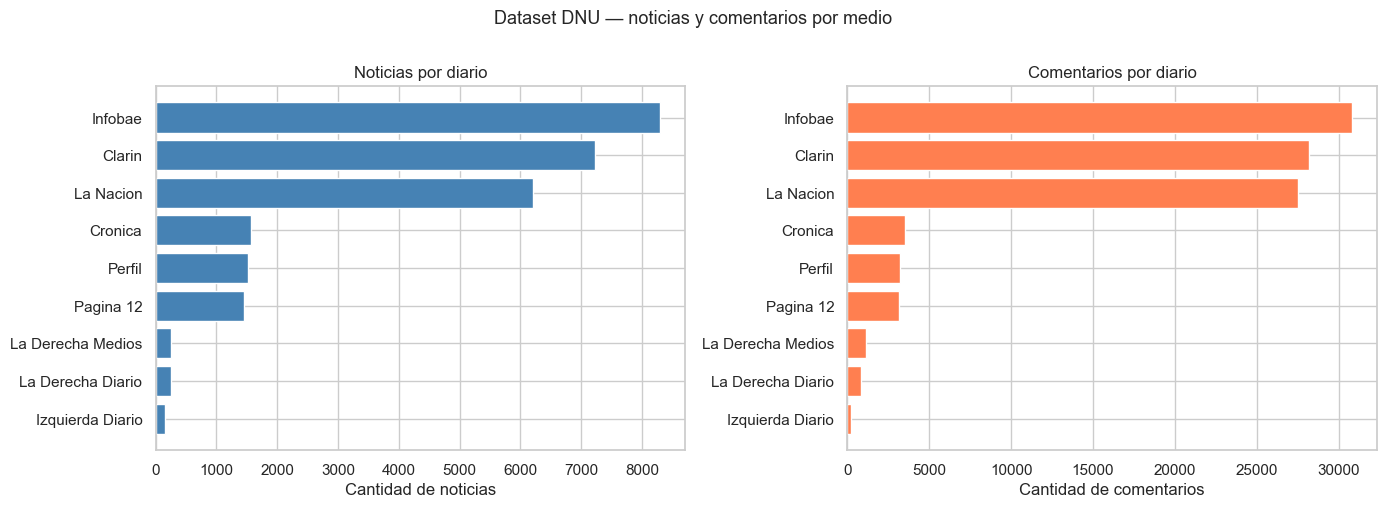

,noticias,comentarios,odiosos,% odio
medio,,,,
infobae,8297,30807,3321,10.78
clarincom,7220,28169,3107,11.03
LANACION,6212,27506,2520,9.16
cronica,1564,3502,732,20.90
perfilcom,1527,3206,261,8.14
pagina12,1461,3133,264,8.43
laderechamedios,252,1140,95,8.33
laderechadiario,256,819,99,12.09
izquierdadiario,156,232,50,21.55


In [10]:
NOMBRES = {
    'clarincom': 'Clarin', 'LANACION': 'La Nacion', 'infobae': 'Infobae',
    'pagina12': 'Pagina 12', 'cronica': 'Cronica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}

dnu_medios = dnu_df.groupby('medio').agg(
    comentarios=('text', 'count'),
    noticias=('tweet_id_noticia', 'nunique'),
    odiosos=('HATEFUL', 'sum'),
).sort_values('comentarios', ascending=False)
dnu_medios['pct_odio'] = (dnu_medios['odiosos'] / dnu_medios['comentarios'] * 100).round(2)

nombres = [NOMBRES.get(m, m) for m in dnu_medios.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(nombres[::-1], dnu_medios['noticias'].values[::-1], color='steelblue')
axes[0].set_title('Noticias por diario')
axes[0].set_xlabel('Cantidad de noticias')
axes[1].barh(nombres[::-1], dnu_medios['comentarios'].values[::-1], color='coral')
axes[1].set_title('Comentarios por diario')
axes[1].set_xlabel('Cantidad de comentarios')
fig.suptitle('Dataset DNU — noticias y comentarios por medio', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('outputs/dnu_kw_medios.png', dpi=150, bbox_inches='tight')
plt.show()

display(dnu_medios.rename(columns={'pct_odio': '% odio'})[['noticias', 'comentarios', 'odiosos', '% odio']])


### 4.3 Serie temporal — noticias por semana

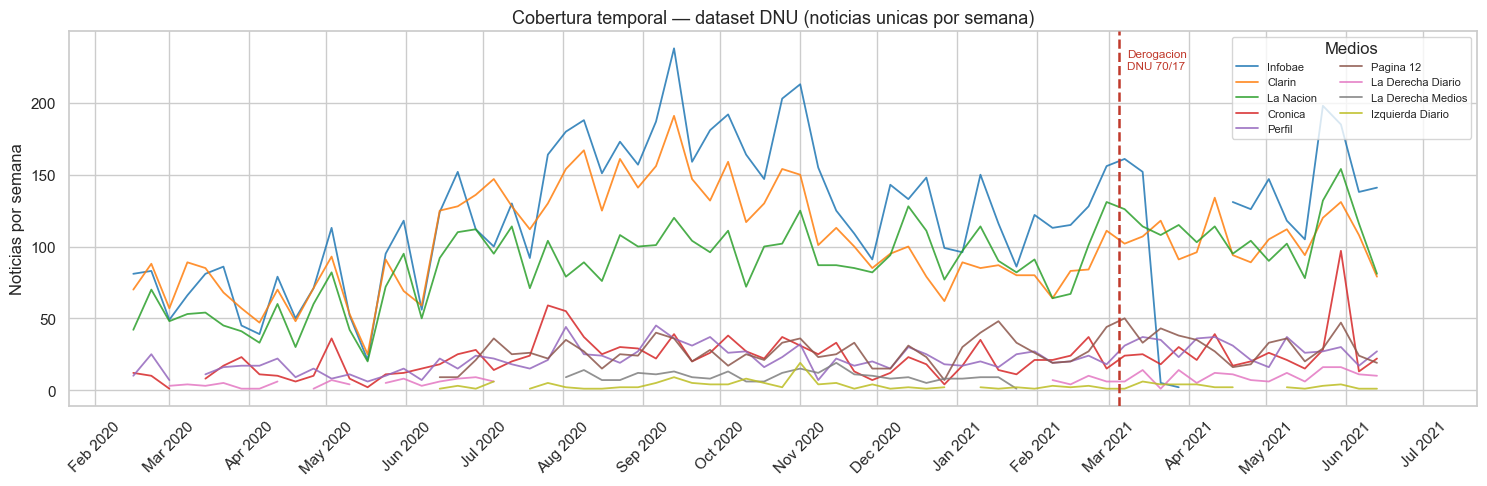

In [11]:
import matplotlib.dates as mdates

dnu_unicas = dnu_df.drop_duplicates(subset=['tweet_id_noticia', 'medio']).copy()
noticias_sem = (
    dnu_unicas
    .groupby(['medio', pd.Grouper(key='date_tweet', freq='W')])['tweet_id_noticia']
    .count()
    .unstack('medio')
)
sem_rango = pd.date_range(noticias_sem.index.min(), noticias_sem.index.max(), freq='W')
noticias_sem = noticias_sem.reindex(sem_rango).replace(0, float('nan'))
orden = noticias_sem.sum().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(15, 5))
colores = plt.cm.tab10.colors
linea_handles = []
for i, medio in enumerate(orden):
    serie = noticias_sem[medio]
    linea, = ax.plot(serie.index, serie.values,
                     label=NOMBRES.get(medio, medio),
                     color=colores[i % len(colores)],
                     linewidth=1.3, alpha=0.85)
    linea_handles.append(linea)

# Marcar derogacion DNU 70/17
ax.axvline(pd.Timestamp('2021-03-05'), color='#c0392b', linewidth=1.8,
           linestyle='--', zorder=5)
ylim = ax.get_ylim()
ax.text(pd.Timestamp('2021-03-08'), ylim[1] * 0.95,
        'Derogacion\nDNU 70/17', color='#c0392b', fontsize=8.5, va='top')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
ax.set_ylabel('Noticias por semana')
ax.set_title('Cobertura temporal — dataset DNU (noticias unicas por semana)', fontsize=13)
ax.legend(handles=linea_handles, loc='upper right', fontsize=8, ncol=2, title='Medios')
plt.tight_layout()
plt.savefig('outputs/dnu_kw_temporal.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.4 Ejemplo de nota — 5 de marzo de 2021

Dia de la derogacion del DNU 70/2017 (decreto de Macri sobre migraciones). El dataset cubre 2020–2021; no hay datos de fechas posteriores.

In [12]:
import html as htmllib
from IPython.display import display, HTML

FECHA_EJEMPLO = '2021-03-05'

mask_fecha = dnu_df['date_tweet'].dt.date == pd.Timestamp(FECHA_EJEMPLO).date()
mask_kw    = dnu_df['title'].str.contains('DNU|Macri|migrac|extranjero', na=False, case=False)
candidatas = (
    dnu_df[mask_fecha & mask_kw]
    .groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
    .size()
    .reset_index(name='n_comentarios')
    .sort_values('n_comentarios', ascending=False)
    .reset_index(drop=True)
)

print(f'{len(candidatas)} noticias sobre DNU el {FECHA_EJEMPLO}:')
display(candidatas[['medio', 'n_comentarios', 'title']].head(5))

row      = candidatas.iloc[0]
tweet_id = row['tweet_id_noticia']
medio    = row['medio']
titulo   = htmllib.escape(str(row['title']))
resumen  = htmllib.escape(str(row['resumen'])[:300])

todos             = dnu_df[dnu_df['tweet_id_noticia'] == tweet_id].copy()
fecha_str         = todos['date_tweet'].min().strftime('%d %b %Y')
total_comentarios = len(todos)
nombre_medio      = NOMBRES.get(medio, medio)
url_tweet         = f'https://twitter.com/{medio}/status/{tweet_id}'

odiosos = todos[todos['HATEFUL'] == 1].head(4)
if len(odiosos) == 0:
    odiosos = todos.head(4)

CATEGORIAS = {
    'RACISM':     ('#c0392b', 'Xenofobia / Racismo'),
    'CALLS':      ('#922b21', 'Llamado a violencia'),
    'WOMEN':      ('#884ea0', 'Odio a mujeres'),
    'LGBTI':      ('#1a5276', 'Odio LGBTI+'),
    'CLASS':      ('#1e8449', 'Odio por clase social'),
    'POLITICS':   ('#d4ac0d', 'Odio politico'),
    'DISABLED':   ('#2471a3', 'Odio a discapacidad'),
    'APPEARANCE': ('#ca6f1e', 'Odio por apariencia'),
    'CRIMINAL':   ('#5d6d7e', 'Estigma criminal'),
}

def make_badges(c_row):
    badges = ''
    for col, (color, label) in CATEGORIAS.items():
        if c_row.get(col, 0) == 1:
            badges += (f'<span style="background:{color};color:white;'
                       f'padding:2px 8px;border-radius:10px;font-size:11px;'
                       f'margin-right:4px;">{label}</span>')
    return badges or '<span style="color:#aaa;font-size:11px;">sin etiqueta</span>'

comentarios_html = ''
for _, c in odiosos.iterrows():
    texto   = htmllib.escape(str(c['text'])[:280])
    fecha_c = c['date_tweet'].strftime('%d %b %Y %H:%M')
    comentarios_html += (
        f'<div style="margin:10px 0 10px 36px;padding:12px 15px;background:#fff;'
        f'border-left:3px solid #e74c3c;border-radius:6px;'
        f'box-shadow:0 1px 3px rgba(0,0,0,0.08);">'
        f'<div style="font-size:12px;color:#888;margin-bottom:6px;">'
        f'Comentario &middot; {fecha_c}</div>'
        f'<div style="font-size:14px;color:#222;line-height:1.6;">{texto}</div>'
        f'<div style="margin-top:8px;">{make_badges(c)}</div>'
        f'</div>'
    )

html_out = (
    f'<div style="font-family:Segoe UI,Arial,sans-serif;max-width:700px;margin:20px auto;">'
    f'<div style="background:#fdf2f2;border-radius:8px;padding:10px 16px;'
    f'margin-bottom:16px;font-size:13px;color:#c0392b;line-height:1.6;">'
    f'<strong>Dataset filtrado DNU</strong><br>'
    f'Noticia del <strong>{FECHA_EJEMPLO}</strong> con <strong>{total_comentarios:,} comentarios</strong>. '
    f'Se muestran hasta 4 clasificados como odiosos.</div>'
    f'<div style="background:#f7f9fa;border:1px solid #dce1e7;border-radius:12px;padding:18px 20px;">'
    f'<div style="display:flex;align-items:center;margin-bottom:12px;">'
    f'<div style="width:42px;height:42px;background:#1da1f2;border-radius:50%;'
    f'display:flex;align-items:center;justify-content:center;'
    f'color:white;font-weight:bold;font-size:17px;margin-right:12px;flex-shrink:0;">{nombre_medio[0]}</div>'
    f'<div><div style="font-weight:700;font-size:14px;color:#14171a;">{nombre_medio}</div>'
    f'<div style="font-size:12px;color:#657786;">@{medio} &middot; {fecha_str}</div></div>'
    f'<div style="margin-left:auto;">'
    f'<span style="background:#1da1f2;color:white;font-size:11px;padding:3px 9px;border-radius:12px;">NOTICIA</span>'
    f'</div></div>'
    f'<div style="font-size:15px;color:#14171a;line-height:1.65;margin-bottom:12px;">{resumen}</div>'
    f'<div style="border:1px solid #dce1e7;border-radius:10px;padding:12px 15px;'
    f'background:white;margin-bottom:12px;">'
    f'<div style="font-size:10px;color:#aaa;text-transform:uppercase;letter-spacing:.5px;margin-bottom:5px;">Titulo</div>'
    f'<div style="font-size:14px;font-weight:600;color:#14171a;line-height:1.45;">{titulo}</div></div>'
    f'<div style="font-size:13px;">'
    f'<a href="{url_tweet}" target="_blank" style="color:#1da1f2;text-decoration:none;">'
    f'Ver tweet original en Twitter/X</a></div></div>'
    f'<div style="margin:8px 0 4px 18px;color:#aaa;font-size:12px;">'
    f'{total_comentarios:,} comentarios en total &mdash; mostrando {len(odiosos)} clasificados como odiosos</div>'
    f'{comentarios_html}</div>'
)

display(HTML(html_out))


17 noticias sobre DNU el 2021-03-05:


,medio,n_comentarios,title
0,clarincom,710,El Gobierno derogó el decreto de Mauricio Macr...
1,infobae,609,El Gobierno derogó el decreto de Macri que imp...
2,LANACION,137,Ley de Migraciones: el Gobierno derogó el decr...
3,infobae,105,El Gobierno derogó el decreto de Macri que imp...
4,infobae,38,El Gobierno derogó el decreto de Macri que imp...


### 4.5 Proporción de odio a lo largo del tiempo

Evolución semanal de la tasa de comentarios HATEFUL en el dataset completo y en el subconjunto filtrado por palabras clave DNU, sin distinguir por medio.

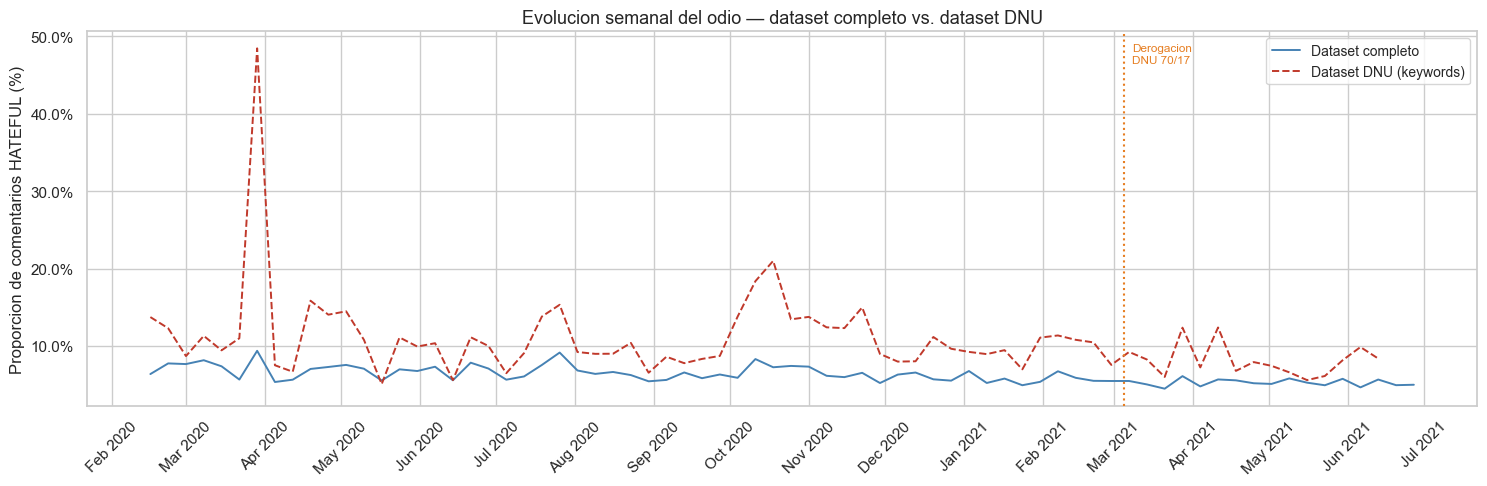

Tasa media de odio — dataset completo: 6.23%
Tasa media de odio — dataset DNU:      10.62%


In [13]:
import matplotlib.dates as mdates

FREQ = 'W'

# --- Proporción semanal de odio en cada dataset ---
def hate_rate_serie(dataframe, freq=FREQ):
    return (
        dataframe
        .set_index('date_tweet')
        .resample(freq)['HATEFUL']
        .agg(hate_rate='mean', n='count')
    )

ts_full = hate_rate_serie(df)
ts_dnu  = hate_rate_serie(dnu_df)

# Filtrar semanas con muy pocos comentarios (ruido)
MIN_COMENTARIOS = 100
ts_full['hate_rate'] = ts_full['hate_rate'].where(ts_full['n'] >= MIN_COMENTARIOS)
ts_dnu['hate_rate']  = ts_dnu['hate_rate'].where(ts_dnu['n'] >= MIN_COMENTARIOS)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(ts_full.index, ts_full['hate_rate'] * 100,
        color='steelblue', linewidth=1.4, label='Dataset completo')
ax.plot(ts_dnu.index,  ts_dnu['hate_rate'] * 100,
        color='#c0392b', linewidth=1.4, linestyle='--', label='Dataset DNU (keywords)')

# Marcar derogacion DNU 70/17
ax.axvline(pd.Timestamp('2021-03-05'), color='#e67e22', linewidth=1.5,
           linestyle=':', zorder=5)
ax.text(pd.Timestamp('2021-03-08'), ax.get_ylim()[1] * 0.97,
        'Derogacion\nDNU 70/17', color='#e67e22', fontsize=8.5, va='top')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}%'))
ax.set_ylabel('Proporcion de comentarios HATEFUL (%)')
ax.set_title('Evolucion semanal del odio — dataset completo vs. dataset DNU', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('outputs/hate_rate_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Tasa media de odio — dataset completo: {ts_full['hate_rate'].mean()*100:.2f}%")
print(f"Tasa media de odio — dataset DNU:      {ts_dnu['hate_rate'].mean()*100:.2f}%")


### 4.6 Dia pico de odio — detalle de notas y comentarios

El dia con mayor tasa de odio en el dataset DNU es el **23 de marzo de 2020** (73.7%), concentrado casi en su totalidad en una nota de Infobae sobre tres extranjeros que incumplian la cuarentena. Se muestran las 2 notas del dia con comentarios odiosos y una muestra de 5 comentarios.

In [14]:
import html as htmllib
from IPython.display import display, HTML
import random

# --- Identificar el dia pico automaticamente ---
ts_diario = (
    dnu_df.set_index('date_tweet')
    .resample('D')['HATEFUL']
    .agg(hate_rate='mean', n='count')
)
ts_diario = ts_diario[ts_diario['n'] >= 30]
dia_pico = ts_diario['hate_rate'].idxmax().date()
hate_pct = ts_diario['hate_rate'].max() * 100
print(f'Dia pico: {dia_pico} | tasa de odio: {hate_pct:.1f}%')

# --- Notas del dia pico, ordenadas por comentarios odiosos ---
mask_dia = dnu_df['date_tweet'].dt.date == dia_pico
dia_df = dnu_df[mask_dia].copy()

notas_dia = (
    dia_df.groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
    .agg(n_total=('text', 'count'), n_odio=('HATEFUL', 'sum'))
    .reset_index()
    .sort_values('n_odio', ascending=False)
    .head(2)
    .reset_index(drop=True)
)

print(f'Total comentarios ese dia: {len(dia_df)} | Odiosos: {dia_df["HATEFUL"].sum()}')
display(notas_dia[['medio', 'n_total', 'n_odio', 'title']])

# --- HTML helpers ---
CATEGORIAS = {
    'RACISM':     ('#c0392b', 'Xenofobia/Racismo'),
    'CALLS':      ('#922b21', 'Llamado a violencia'),
    'WOMEN':      ('#884ea0', 'Odio a mujeres'),
    'LGBTI':      ('#1a5276', 'Odio LGBTI+'),
    'CLASS':      ('#1e8449', 'Clase social'),
    'POLITICS':   ('#d4ac0d', 'Odio politico'),
    'DISABLED':   ('#2471a3', 'Discapacidad'),
    'APPEARANCE': ('#ca6f1e', 'Apariencia'),
    'CRIMINAL':   ('#5d6d7e', 'Estigma criminal'),
}
NOMBRES = {
    'clarincom': 'Clarin', 'LANACION': 'La Nacion', 'infobae': 'Infobae',
    'pagina12': 'Pagina 12', 'cronica': 'Cronica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}

def make_badges(c_row):
    badges = ''.join(
        f'<span style="background:{color};color:white;padding:2px 7px;border-radius:10px;'
        f'font-size:11px;margin-right:3px;">{label}</span>'
        for col, (color, label) in CATEGORIAS.items() if c_row.get(col, 0) == 1
    )
    return badges or '<span style="color:#aaa;font-size:11px;">sin etiqueta especifica</span>'

def render_nota(row, comentarios_df, n_comentarios=5, seed=42):
    tweet_id     = row['tweet_id_noticia']
    medio        = row['medio']
    nombre_medio = NOMBRES.get(medio, medio)
    titulo       = htmllib.escape(str(row['title']))
    resumen      = htmllib.escape(str(row['resumen'])[:280])
    n_total      = int(row['n_total'])
    n_odio       = int(row['n_odio'])
    pct          = round(n_odio / n_total * 100, 1) if n_total > 0 else 0
    fecha_str    = dia_df[dia_df['tweet_id_noticia'] == tweet_id]['date_tweet'].min().strftime('%d %b %Y')
    url_tweet    = f'https://twitter.com/{medio}/status/{tweet_id}'

    muestra = comentarios_df.sample(min(n_comentarios, len(comentarios_df)),
                                    random_state=seed)

    comentarios_html = ''
    for _, c in muestra.iterrows():
        texto   = htmllib.escape(str(c['text'])[:300])
        fecha_c = c['date_tweet'].strftime('%d %b %Y %H:%M')
        comentarios_html += (
            f'<div style="margin:8px 0 8px 32px;padding:10px 14px;background:#fff;'
            f'border-left:3px solid #e74c3c;border-radius:6px;'
            f'box-shadow:0 1px 3px rgba(0,0,0,0.07);">'
            f'<div style="font-size:11px;color:#999;margin-bottom:5px;">{fecha_c}</div>'
            f'<div style="font-size:13px;color:#222;line-height:1.55;">{texto}</div>'
            f'<div style="margin-top:6px;">{make_badges(c)}</div>'
            f'</div>'
        )

    return (
        f'<div style="margin-bottom:28px;">'
        # Cabecera nota
        f'<div style="background:#f7f9fa;border:1px solid #dce1e7;border-radius:12px;padding:16px 18px;">'
        f'<div style="display:flex;align-items:center;margin-bottom:10px;">'
        f'<div style="width:38px;height:38px;background:#1da1f2;border-radius:50%;'
        f'display:flex;align-items:center;justify-content:center;'
        f'color:white;font-weight:bold;font-size:16px;margin-right:10px;flex-shrink:0;">{nombre_medio[0]}</div>'
        f'<div>'
        f'<div style="font-weight:700;font-size:13px;color:#14171a;">{nombre_medio}</div>'
        f'<div style="font-size:11px;color:#657786;">@{medio} &middot; {fecha_str}</div>'
        f'</div>'
        f'<div style="margin-left:auto;display:flex;gap:6px;align-items:center;">'
        f'<span style="background:#e74c3c;color:white;font-size:11px;padding:3px 8px;border-radius:10px;">'
        f'{pct}% odio ({n_odio}/{n_total})</span>'
        f'<span style="background:#1da1f2;color:white;font-size:11px;padding:3px 8px;border-radius:10px;">NOTICIA</span>'
        f'</div></div>'
        # Titulo
        f'<div style="font-size:14px;font-weight:600;color:#14171a;line-height:1.4;margin-bottom:8px;">{titulo}</div>'
        f'<div style="font-size:13px;color:#555;line-height:1.55;margin-bottom:10px;">{resumen}</div>'
        f'<a href="{url_tweet}" target="_blank" style="color:#1da1f2;font-size:12px;text-decoration:none;">'
        f'Ver tweet original</a>'
        f'</div>'
        # Comentarios
        f'<div style="margin:6px 0 0 8px;color:#aaa;font-size:11px;">'
        f'Muestra de {len(muestra)} comentarios odiosos (de {n_odio} totales)</div>'
        f'{comentarios_html}'
        f'</div>'
    )

# --- Renderizar las 2 notas ---
bloques = ''
for _, row in notas_dia.iterrows():
    tid       = row['tweet_id_noticia']
    odiosos   = dia_df[(dia_df['tweet_id_noticia'] == tid) & (dia_df['HATEFUL'] == 1)]
    n_mostrar = 5 if _ == 0 else min(5, len(odiosos))  # 5 para nota 1, hasta 5 para nota 2
    bloques  += render_nota(row, odiosos, n_comentarios=n_mostrar)

html_out = (
    f'<div style="font-family:Segoe UI,Arial,sans-serif;max-width:720px;margin:20px auto;">'
    f'<div style="background:#fdf2f2;border-left:4px solid #c0392b;border-radius:6px;'
    f'padding:10px 16px;margin-bottom:20px;font-size:13px;color:#c0392b;line-height:1.6;">'
    f'<strong>Dia pico: {dia_pico}</strong> &mdash; tasa de odio: <strong>{hate_pct:.1f}%</strong> '
    f'({dia_df["HATEFUL"].sum()} de {len(dia_df)} comentarios)<br>'
    f'El 89.9% del odio proviene de una sola nota sobre extranjeros que incumplian la cuarentena obligatoria.'
    f'</div>'
    f'{bloques}'
    f'</div>'
)

display(HTML(html_out))


Dia pico: 2020-03-23 | tasa de odio: 73.7%
Total comentarios ese dia: 358 | Odiosos: 264


,medio,n_total,n_odio,title
0,infobae,287,258,Tres extranjeros incumplían la cuarentena tota...
1,perfilcom,1,1,Cristina y Florencia Kirchner regresaron para ...


### 4.7 Serie temporal de odio (dataset DNU) con cronología COVID-19

Evolución semanal de la tasa de comentarios HATEFUL en el dataset filtrado por palabras clave DNU. El fondo sombreado corresponde a los distintos períodos de la pandemia; las líneas verticales marcan eventos clave (negro: nivel 1 / rojo grueso: nivel 3).

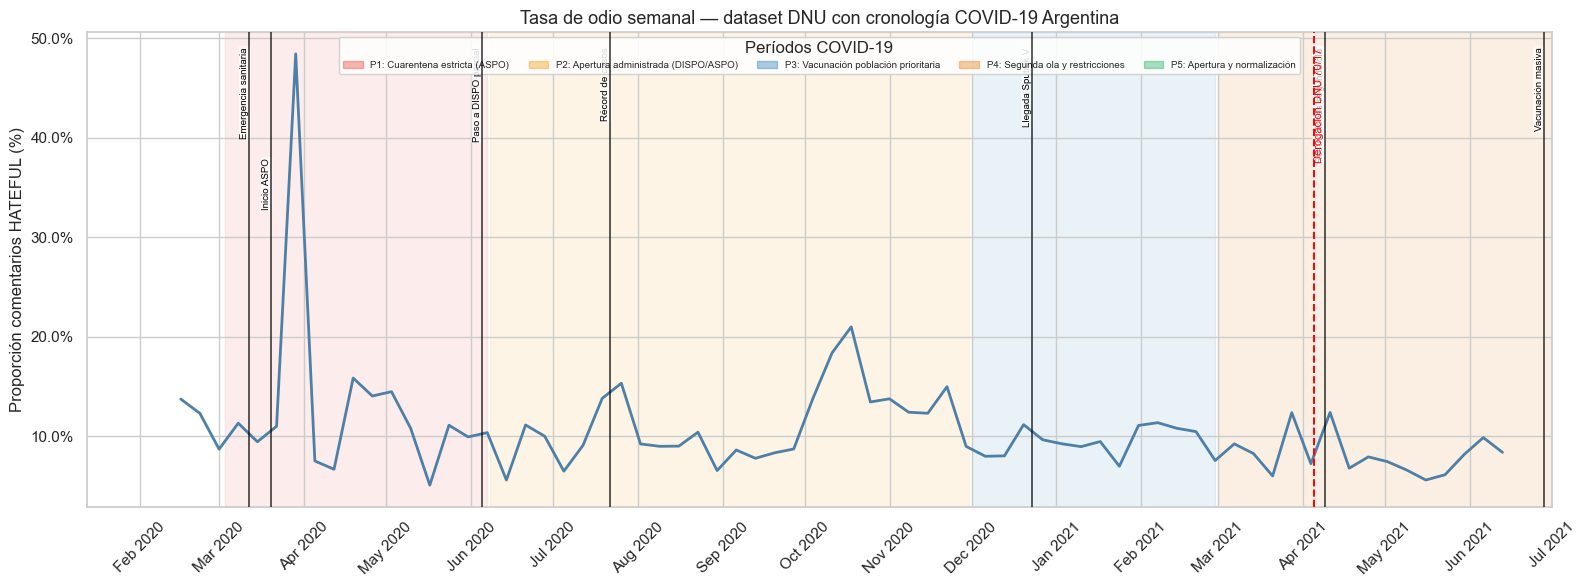

In [15]:
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# ── Cargar cronología ─────────────────────────────────────────────────────
xl       = pd.ExcelFile("data/covid_argentina_cronologia_con_periodos.xlsx")
periodos = xl.parse("Periodos")
eventos  = xl.parse("eventos")

def parse_fecha(s):
    s = str(s).strip()
    for fmt in ("%d-%m-%Y", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d"):
        try:
            return pd.to_datetime(s, format=fmt)
        except ValueError:
            continue
    return pd.NaT

eventos["fecha_dt"] = eventos["Fecha"].apply(parse_fecha)
ev1 = eventos[eventos["Nivel"] == 1].dropna(subset=["fecha_dt"])
ev3 = eventos[eventos["Nivel"] == 3].dropna(subset=["fecha_dt"])

# ── Serie temporal DNU (semanal) ──────────────────────────────────────────
ts_dnu = (
    dnu_df.set_index("date_tweet")
    .resample("W")["HATEFUL"]
    .agg(hate_rate="mean", n="count")
)
ts_dnu["hate_rate"] = ts_dnu["hate_rate"].where(ts_dnu["n"] >= 30)

# ── Colores de períodos ───────────────────────────────────────────────────
COLORES_PERIODO = {
    1: ("#e74c3c", 0.10),
    2: ("#f39c12", 0.10),
    3: ("#2980b9", 0.10),
    4: ("#e67e22", 0.12),
    5: ("#27ae60", 0.10),
}

# ── Gráfico ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Sombreado de períodos
periodo_handles = []
for _, row in periodos.iterrows():
    pid = int(row["Periodo"])
    color, alpha = COLORES_PERIODO.get(pid, ("#aaaaaa", 0.10))
    ax.axvspan(row["Fecha inicio"], row["Fecha fin"],
               color=color, alpha=alpha, zorder=0)
    patch = mpatches.Patch(color=color, alpha=0.4,
                           label=f"P{pid}: {row['Nombre del período']}")
    periodo_handles.append(patch)

# Serie DNU — azul apagado
ax.plot(ts_dnu.index, ts_dnu["hate_rate"] * 100,
        color="#4e7fa6", linewidth=2.0, zorder=5)

# ── Eventos nivel 1: líneas negras ────────────────────────────────────────
ev1_sorted = ev1.sort_values("fecha_dt").reset_index(drop=True)
prev_fecha, nivel_offset, offsets = None, 0, []
for _, ev in ev1_sorted.iterrows():
    if prev_fecha is not None and (ev["fecha_dt"] - prev_fecha).days < 20:
        nivel_offset = (nivel_offset + 1) % 3
    else:
        nivel_offset = 0
    offsets.append(nivel_offset)
    prev_fecha = ev["fecha_dt"]
ev1_sorted["label_offset"] = offsets

ylim = ax.get_ylim()
for _, ev in ev1_sorted.iterrows():
    ax.axvline(ev["fecha_dt"], color="black", linewidth=1.2,
               linestyle="-", zorder=6, alpha=0.75)
    y_frac = 0.97 - ev["label_offset"] * 0.22
    ax.text(ev["fecha_dt"], ylim[1] * y_frac,
            ev["Suceso corto"], fontsize=7, color="black",
            rotation=90, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.6, ec="none"))

# ── Eventos nivel 3: línea roja punteada (sin negrita) ────────────────────
for _, ev in ev3.iterrows():
    ax.axvline(ev["fecha_dt"], color="red", linewidth=1.4,
               linestyle="--", zorder=7)
    ax.text(ev["fecha_dt"], ylim[1] * 0.97,
            ev["Suceso corto"], fontsize=8, color="red",
            rotation=90, va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.7, ec="none"))

# ── Límite temporal: hasta junio 2021 ─────────────────────────────────────
ax.set_xlim(right=pd.Timestamp("2021-07-01"))

# ── Leyenda solo de períodos — arriba al centro ───────────────────────────
ax.legend(handles=periodo_handles, loc="upper center", fontsize=7,
          ncol=5, title="Períodos COVID-19", framealpha=0.85,
          bbox_to_anchor=(0.5, 1.0))

# ── Formato ───────────────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.set_ylabel("Proporción comentarios HATEFUL (%)")
ax.set_title("Tasa de odio semanal — dataset DNU con cronología COVID-19 Argentina", fontsize=13)

plt.tight_layout()
plt.savefig("outputs/dnu_hate_cronologia.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.8 Análisis del día pico: 23 de marzo de 2020

Distribución del odio por medio y por categoría, y verificación de comentarios repetidos.

Dia: 2020-03-23 | Total comentarios: 358 | Odiosos: 264 (73.7%)


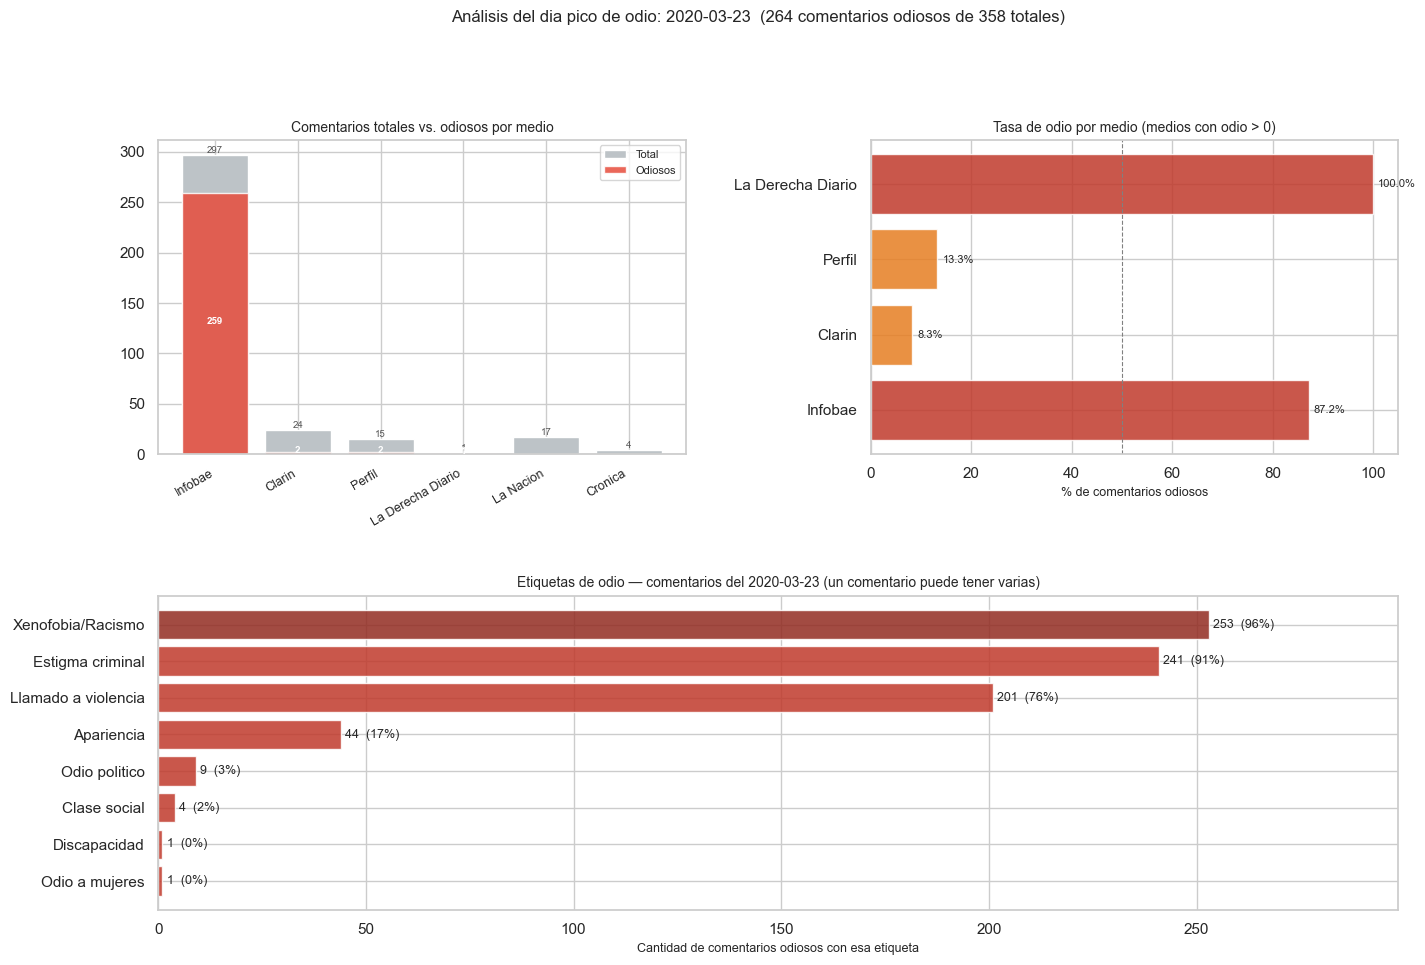


Comentarios con texto duplicado: 7 (2.0%)
Duplicados exactos (mismo texto + mismo usuario): 0

Textos repetidos:


,texto,repeticiones
0,@infobae Arafue,3
1,@infobae A su país,2
2,@infobae Deportarlos,2


In [18]:
LABELS = ['CALLS','WOMEN','LGBTI','RACISM','CLASS','POLITICS','DISABLED','APPEARANCE','CRIMINAL']
LABEL_NAMES = {
    'CALLS': 'Llamado a violencia', 'WOMEN': 'Odio a mujeres', 'LGBTI': 'Odio LGBTI+',
    'RACISM': 'Xenofobia/Racismo', 'CLASS': 'Clase social', 'POLITICS': 'Odio politico',
    'DISABLED': 'Discapacidad', 'APPEARANCE': 'Apariencia', 'CRIMINAL': 'Estigma criminal',
}
NOMBRES = {
    'clarincom': 'Clarin', 'LANACION': 'La Nacion', 'infobae': 'Infobae',
    'pagina12': 'Pagina 12', 'cronica': 'Cronica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}

# ── Subconjunto del día ───────────────────────────────────────────────────────
DIA_PICO = '2020-03-23'
mask_dia  = dnu_df['date_tweet'].dt.date == pd.Timestamp(DIA_PICO).date()
dia_df    = dnu_df[mask_dia].copy()
odio_df   = dia_df[dia_df['HATEFUL'] == 1]

print(f'Dia: {DIA_PICO} | Total comentarios: {len(dia_df)} | Odiosos: {len(odio_df)} ({len(odio_df)/len(dia_df)*100:.1f}%)')

# ── Por medio ─────────────────────────────────────────────────────────────────
by_medio = (
    dia_df.groupby('medio')
    .agg(total=('HATEFUL', 'count'), odio=('HATEFUL', 'sum'))
    .assign(pct=lambda x: (x.odio / x.total * 100).round(1))
    .sort_values('odio', ascending=False)
)
by_medio.index = [NOMBRES.get(m, m) for m in by_medio.index]

# ── Por etiqueta (sobre comentarios odiosos) ──────────────────────────────────
label_counts = pd.Series(
    {LABEL_NAMES[l]: int(odio_df[l].sum()) for l in LABELS}
).sort_values(ascending=True)

# ── Duplicados ────────────────────────────────────────────────────────────────
dup_texto   = dia_df.duplicated(subset=['text'], keep=False)
dup_exactos = dia_df.duplicated(subset=['text', 'user_id'], keep=False)
dup_groups  = (
    dia_df[dup_texto]
    .groupby('text')
    .size()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={0: 'repeticiones', 'text': 'texto'})
)

# ── Figura con 3 paneles ──────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])   # comentarios totales vs odiosos por medio
ax2 = fig.add_subplot(gs[0, 1])   # % odio por medio
ax3 = fig.add_subplot(gs[1, :])   # etiquetas

# Panel 1: comentarios totales vs odiosos por medio
x    = range(len(by_medio))
bars = ax1.bar(x, by_medio['total'], color='#bdc3c7', label='Total')
ax1.bar(x, by_medio['odio'], color='#e74c3c', alpha=0.85, label='Odiosos')
ax1.set_xticks(list(x))
ax1.set_xticklabels(by_medio.index, rotation=30, ha='right', fontsize=9)
ax1.set_title('Comentarios totales vs. odiosos por medio', fontsize=10)
ax1.legend(fontsize=8)
for i, (tot, od) in enumerate(zip(by_medio['total'], by_medio['odio'])):
    ax1.text(i, tot + 2, str(tot), ha='center', fontsize=7, color='#555')
    if od > 0:
        ax1.text(i, od / 2, str(od), ha='center', fontsize=7, color='white', fontweight='bold')

# Panel 2: % odio por medio (solo medios con al menos 1 odioso)
by_medio_odio = by_medio[by_medio['odio'] > 0]
colores_barra = ['#c0392b' if p > 50 else '#e67e22' for p in by_medio_odio['pct']]
ax2.barh(by_medio_odio.index, by_medio_odio['pct'], color=colores_barra, alpha=0.85)
ax2.set_xlabel('% de comentarios odiosos', fontsize=9)
ax2.set_title('Tasa de odio por medio (medios con odio > 0)', fontsize=10)
ax2.axvline(50, color='gray', linewidth=0.8, linestyle='--')
for i, (idx, row) in enumerate(by_medio_odio.iterrows()):
    ax2.text(row['pct'] + 1, i, f"{row['pct']}%", va='center', fontsize=8)

# Panel 3: etiquetas (barras horizontales, solo las > 0)
label_counts_pos = label_counts[label_counts > 0]
colores_label = ['#922b21' if v == label_counts_pos.max() else '#c0392b' for v in label_counts_pos]
ax3.barh(label_counts_pos.index, label_counts_pos.values, color=colores_label, alpha=0.85)
ax3.set_xlabel('Cantidad de comentarios odiosos con esa etiqueta', fontsize=9)
ax3.set_title(f'Etiquetas de odio — comentarios del {DIA_PICO} (un comentario puede tener varias)', fontsize=10)
for i, (cat, val) in enumerate(label_counts_pos.items()):
    pct = val / len(odio_df) * 100
    ax3.text(val + 1, i, f'{val}  ({pct:.0f}%)', va='center', fontsize=9)
ax3.set_xlim(right=label_counts_pos.max() * 1.18)

fig.suptitle(f'Análisis del dia pico de odio: {DIA_PICO}  ({len(odio_df)} comentarios odiosos de {len(dia_df)} totales)',
             fontsize=12, y=1.01)
plt.savefig('outputs/analisis_pico_odio.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Duplicados ────────────────────────────────────────────────────────────────
print(f'\nComentarios con texto duplicado: {dup_texto.sum()} ({dup_texto.sum()/len(dia_df)*100:.1f}%)')
print(f'Duplicados exactos (mismo texto + mismo usuario): {dup_exactos.sum()}')
if len(dup_groups) > 0:
    print('\nTextos repetidos:')
    display(dup_groups)
else:
    print('Sin comentarios repetidos.')


### 4.9 Noticias que generaron el odio del 23 de marzo de 2020

Siete artículos distintos recibieron comentarios odiosos ese día, pero prácticamente todo el odio provino de una sola nota de Infobae.

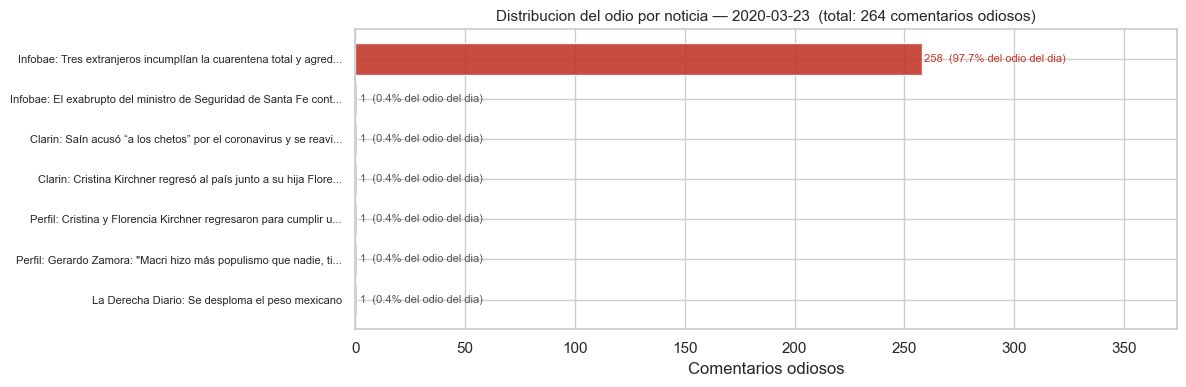

In [19]:
import html as htmllib
from IPython.display import display, HTML

NOMBRES = {
    'clarincom': 'Clarin', 'LANACION': 'La Nacion', 'infobae': 'Infobae',
    'pagina12': 'Pagina 12', 'cronica': 'Cronica', 'perfilcom': 'Perfil',
    'laderechamedios': 'La Derecha Medios', 'laderechadiario': 'La Derecha Diario',
    'izquierdadiario': 'Izquierda Diario',
}
LABEL_COLS = ['RACISM', 'CRIMINAL', 'CALLS', 'APPEARANCE', 'POLITICS',
              'CLASS', 'WOMEN', 'LGBTI', 'DISABLED']
LABEL_NAMES = {
    'RACISM': 'Xenofobia', 'CRIMINAL': 'Estigma criminal',
    'CALLS': 'Llamado a violencia', 'APPEARANCE': 'Apariencia',
    'POLITICS': 'Odio politico', 'CLASS': 'Clase social',
    'WOMEN': 'Odio a mujeres', 'LGBTI': 'Odio LGBTI+', 'DISABLED': 'Discapacidad',
}

# ── Armar tabla de noticias con odio ─────────────────────────────────────────
DIA_PICO = '2020-03-23'
mask_dia = dnu_df['date_tweet'].dt.date == pd.Timestamp(DIA_PICO).date()
dia_df   = dnu_df[mask_dia].copy()
odio_df  = dia_df[dia_df['HATEFUL'] == 1]

agg_dict = {'n_odio': ('HATEFUL', 'sum'), 'n_total': ('text', 'count')}
for lc in LABEL_COLS:
    agg_dict[lc] = (lc, 'sum')

notas = (
    odio_df.groupby(['tweet_id_noticia', 'medio', 'title', 'resumen'])
    .agg(**agg_dict)
    .reset_index()
    .sort_values('n_odio', ascending=False)
    .reset_index(drop=True)
)
notas['pct'] = (notas['n_odio'] / notas['n_total'] * 100).round(1)
total_odio   = notas['n_odio'].sum()

# ── Gráfico: participación de cada nota en el odio total ─────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

titulos_cortos = [
    f"{NOMBRES.get(r['medio'], r['medio'])}: {str(r['title'])[:55]}..."
    if len(str(r['title'])) > 55
    else f"{NOMBRES.get(r['medio'], r['medio'])}: {r['title']}"
    for _, r in notas.iterrows()
]
colores = ['#c0392b' if v == notas['n_odio'].max() else '#aab4be' for v in notas['n_odio']]

bars = ax.barh(range(len(notas)), notas['n_odio'], color=colores, alpha=0.9)
ax.set_yticks(range(len(notas)))
ax.set_yticklabels(titulos_cortos, fontsize=8)
ax.set_xlabel('Comentarios odiosos')
ax.set_title(f'Distribucion del odio por noticia — {DIA_PICO}  (total: {total_odio} comentarios odiosos)', fontsize=11)

for i, (val, pct_total) in enumerate(zip(notas['n_odio'], notas['n_odio'] / total_odio * 100)):
    ax.text(val + 1, i, f'{val}  ({pct_total:.1f}% del odio del dia)',
            va='center', fontsize=8,
            color='#c0392b' if val == notas['n_odio'].max() else '#555')

ax.set_xlim(right=notas['n_odio'].max() * 1.45)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/noticias_pico_odio.png', dpi=150, bbox_inches='tight')
plt.show()

# ── HTML: tarjetas por noticia ────────────────────────────────────────────────
def badge_label(label, n, total):
    if n == 0:
        return ''
    pct = round(n / total * 100)
    COLORES_L = {
        'RACISM': '#c0392b', 'CRIMINAL': '#5d6d7e', 'CALLS': '#922b21',
        'APPEARANCE': '#ca6f1e', 'POLITICS': '#d4ac0d', 'CLASS': '#1e8449',
        'WOMEN': '#884ea0', 'LGBTI': '#1a5276', 'DISABLED': '#2471a3',
    }
    color = COLORES_L.get(label, '#888')
    return (
        f'<span style="background:{color};color:white;padding:2px 7px;'
        f'border-radius:10px;font-size:11px;margin:2px;display:inline-block;">'
        f'{LABEL_NAMES[label]}: {n} ({pct}%)</span>'
    )

tarjetas = ''
for _, r in notas.iterrows():
    es_principal = r['n_odio'] == notas['n_odio'].max()
    pct_del_dia  = r['n_odio'] / total_odio * 100
    medio        = r['medio']
    nombre_medio = NOMBRES.get(medio, medio)
    titulo       = htmllib.escape(str(r['title']))
    resumen      = htmllib.escape(str(r['resumen'])[:220])
    url_tweet    = f'https://twitter.com/{medio}/status/{int(r["tweet_id_noticia"])}'
    borde        = '#c0392b' if es_principal else '#dce1e7'
    bg_header    = '#fdf2f2' if es_principal else '#f7f9fa'

    badges = ''.join(badge_label(lc, int(r[lc]), r['n_odio']) for lc in LABEL_COLS)

    tarjetas += (
        f'<div style="border:1.5px solid {borde};border-radius:10px;margin-bottom:14px;overflow:hidden;">'
        # cabecera
        f'<div style="background:{bg_header};padding:10px 14px;display:flex;align-items:center;gap:10px;">'
        f'<div style="width:34px;height:34px;background:#1da1f2;border-radius:50%;'
        f'display:flex;align-items:center;justify-content:center;'
        f'color:white;font-weight:bold;font-size:14px;flex-shrink:0;">{nombre_medio[0]}</div>'
        f'<div style="flex:1;">'
        f'<div style="font-weight:700;font-size:13px;">{nombre_medio}</div>'
        f'<div style="font-size:11px;color:#657786;">@{medio}</div>'
        f'</div>'
        f'<div style="text-align:right;font-size:12px;">'
        f'<span style="background:#e74c3c;color:white;padding:3px 8px;border-radius:8px;font-weight:bold;">'
        f'{r["n_odio"]} odiosos</span><br>'
        f'<span style="color:#888;font-size:11px;">{pct_del_dia:.1f}% del odio del dia</span>'
        f'</div></div>'
        # cuerpo
        f'<div style="padding:10px 14px;">'
        f'<div style="font-size:13px;font-weight:600;margin-bottom:5px;">{titulo}</div>'
        f'<div style="font-size:12px;color:#555;margin-bottom:8px;">{resumen}</div>'
        f'<div style="margin-bottom:6px;">{badges}</div>'
        f'<a href="{url_tweet}" target="_blank" style="font-size:11px;color:#1da1f2;">Ver tweet</a>'
        f'</div></div>'
    )

html_out = (
    f'<div style="font-family:Segoe UI,Arial,sans-serif;max-width:750px;margin:16px auto;">'
    f'<div style="background:#fdf2f2;border-left:4px solid #c0392b;border-radius:6px;'
    f'padding:10px 16px;margin-bottom:18px;font-size:13px;line-height:1.6;">'
    f'<strong>{len(notas)} noticias</strong> recibieron comentarios odiosos el {DIA_PICO}. '
    f'La nota principal concentra <strong>{notas.iloc[0]["n_odio"]} de {total_odio} comentarios '
    f'odiosos ({notas.iloc[0]["n_odio"]/total_odio*100:.1f}%)</strong>.'
    f'</div>'
    f'{tarjetas}'
    f'</div>'
)
display(HTML(html_out))
